# Project Minerva — Week 5: Multi-Agent Collective Intelligence
Gossip phase (QSG model) built on top of the Week 4 bidding game.

Extends Week 4's game with a 3-round gossip phase before each round's bid is locked in, then sweeps
group size N = 3, 5, 10 across 10 seeds each to find the drift-selection crossover.

In [1]:
!pip install groq langgraph langchain-groq python-dotenv numpy matplotlib scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.4/557.4 kB 13.3 MB/s eta 0:00:00
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.3.1
    Uninstalling langchain-core-1.3.1:
      Successfully uninstalled langchain-core-1.3.1


In [2]:
import os
import json
import random
import numpy as np
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from groq import Groq
from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage, HumanMessage

In [3]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
api_key = user_secrets.get_secret("GROQ_API_KEY")
# load_dotenv()
# api_key = os.getenv("GROQ_API_KEY")
client = Groq(api_key=api_key)
llm = ChatGroq(model="llama-3.1-8b-instant", 
              api_key=api_key)

## Personas
Same five personalities as Week 4. When N > 5 the list is cycled; when N < 5, the first N are used.

In [4]:
PERSONA_ORDER = ["Agressive", "Cautious", "Random", "Analyst", "Cooperative"]

PERSONA_TEXT = {
    "Agressive": """You are a smart rational bidder with an aggressive playstyle.
Your primary objective is survival.
You are willing to spend significantly more points than other players if doing so increases your chance of surviving.
When estimating the threshold, you use larger safety margins than most players.
You prefer to bid near the upper end of your estimated safe range.""",

    "Cautious": """You are a smart rational bidder with a frugal playstyle.
Your primary objective is to conserve points while still surviving.
You use the smallest safety margin that you believe is reasonable.
You prefer to bid near the lower end of your estimated safe range.""",

    "Random": """You are a smart rational bidder who has a wild playstyle. You like to fluctuate the value of your bids.
You predict a threshold range (and add some amount for safety) and bid randomly within it.
But you still keep survival as your priority, so you would not bid higher (wasting points) or lower
(risking elimination) than what you expect the threshold to be.""",

    "Analyst": """You are a smart rational bidder with an analytical playstyle.
Your primary objective is survival while minimizing unnecessary point expenditure.
You carefully analyze the round number, remaining points, bid histories, and eliminations before deciding.
You should not consistently bid extremely high or extremely low. Choose the bid best justified by the evidence.""",

    "Cooperative": """You are a smart rational bidder with a cooperative playstyle.
You prefer not to deviate significantly from the typical bid of other players.
Estimate the average bid of active players from historical data and use it as one signal among many.
Avoid bids that are extreme outliers unless the evidence strongly supports them.""",
}


def build_agents(N):
    """Return (agent_names, persona_of_agent) for a group of size N,
    cycling PERSONA_ORDER and appending an index suffix for uniqueness."""
    agent_names = []
    persona_of = {}
    for i in range(N):
        persona = PERSONA_ORDER[i % len(PERSONA_ORDER)]
        name = f"{persona}{i}"
        agent_names.append(name)
        persona_of[name] = persona
    return agent_names, persona_of

## Ring Topology
Before each full game, agents are randomly assigned into a fixed ring using the run's seed.
`neighbor_of[a]` is the agent immediately ahead of `a` in the shuffled ring — the agent `a`
gossips with. This mapping stays fixed for all 10 rounds and all 3 gossip sub-rounds within a round.

In [5]:
def assign_ring(agent_names, seed):
    rng = random.Random(seed)
    order = list(agent_names)
    rng.shuffle(order)
    neighbor_of = {}
    N = len(order)
    for idx, agent in enumerate(order):
        neighbor_of[agent] = order[(idx + 1) % N]
    return neighbor_of

## Gossip LLM Calls
`generate_intended_bid` produces each agent's initial draft bid + confidence for the round.
`gossip_update` reconsiders a bid after seeing a neighbor's bid + confidence.
Both fall back to the agent's previous value (and log the failure) if the LLM output can't be parsed
as valid JSON with a positive-integer bid.

In [6]:
def _safe_parse(raw_content):
    return json.loads(raw_content)


def generate_intended_bid(agent_name, persona_text, round_number, threshold, resources, history):
    system_message = SystemMessage(content=f"""Personality: {persona_text}

You are about to bid in round {round_number}. The threshold this round is {threshold}.
Your current resources are {resources}. The round history so far is: {history}.
State your intended bid and how confident you are.
Output JSON only:
{{"intended_bid": <integer>, "confidence": <integer 1-10>, "reasoning": "<one sentence>"}}""")
    human_message = HumanMessage(content="Provide your intended bid now. JSON only.")

    try:
        response = llm.invoke([system_message, human_message])
        data = _safe_parse(response.content)
        bid = int(data["intended_bid"])
        confidence = int(data["confidence"])
        reasoning = data.get("reasoning", "")
        if bid <= 0:
            raise ValueError("non-positive bid")
        return bid, confidence, reasoning
    except Exception as e:
        fallback_bid = max(1, min(resources, threshold))
        fallback_conf = 5
        print(f"[PARSE FAIL - intended_bid] {agent_name}: {e}. Falling back to {fallback_bid}.")
        return fallback_bid, fallback_conf, "fallback: parse failure"


def gossip_update(agent_name, persona_text, current_bid, my_confidence, neighbor_bid, neighbor_confidence):
    system_message = SystemMessage(content=f"""Personality: {persona_text}

You intended to bid {current_bid} with confidence {my_confidence}/10.
Your neighbor bid {neighbor_bid} with confidence {neighbor_confidence}/10.
Reconsider your bid in light of this. Output JSON only, no other text:
{{"updated_bid": <integer>, "confidence": <integer 1-10>, "reasoning": "<one sentence>"}}""")
    human_message = HumanMessage(content="Update now. JSON only.")

    try:
        response = llm.invoke([system_message, human_message])
        data = _safe_parse(response.content)
        bid = int(data["updated_bid"])
        confidence = int(data["confidence"])
        reasoning = data.get("reasoning", "")
        if bid <= 0:
            raise ValueError("non-positive bid")
        return bid, confidence, reasoning
    except Exception as e:
        print(f"[PARSE FAIL - updated_bid] {agent_name}: {e}. Keeping previous bid {current_bid}.")
        return current_bid, my_confidence, "fallback: kept previous bid"


def weighted_update(my_bid, my_conf, neighbor_bid, neighbor_conf):
    """Deterministic fallback formula, useful for debugging the gossip logic
    without relying on LLM updates. Not used in the final LLM-driven run below."""
    total_conf = my_conf + neighbor_conf
    return round((my_bid * my_conf + neighbor_bid * neighbor_conf) / total_conf)

## Gossip Phase (3 sub-rounds)

In [7]:
def run_gossip_phase(agents, persona_of, neighbor_of, round_number, threshold, resources, history,
                      last_bid_conf, verbose=False):
    """Runs the initial draft + 3 gossip sub-rounds for one round of the game.

    `last_bid_conf` holds each agent's most recent (bid, confidence) snapshot -- used as a
    stand-in for eliminated agents whose ring neighbor slot still points at them.
    Returns (initial_bids, initial_confs, initial_reasons, final_bids, final_confs, final_reasons, consensus_bid).
    """
    intended_bids, intended_confs, intended_reasons = {}, {}, {}
    for a in agents:
        bid, conf, reasoning = generate_intended_bid(a, persona_of[a], round_number, threshold, resources[a], history)
        intended_bids[a] = bid
        intended_confs[a] = conf
        intended_reasons[a] = reasoning
        last_bid_conf[a] = (bid, conf)

    current_bids = dict(intended_bids)
    current_confs = dict(intended_confs)
    current_reasons = dict(intended_reasons)

    for sub_round in range(1, 4):
        new_bids, new_confs, new_reasons = {}, {}, {}
        for a in agents:
            neighbor = neighbor_of[a]
            n_bid, n_conf = last_bid_conf.get(neighbor, (current_bids[a], current_confs[a])) \
                if neighbor not in current_bids else (current_bids[neighbor], current_confs[neighbor])
            bid, conf, reasoning = gossip_update(a, persona_of[a], current_bids[a], current_confs[a], n_bid, n_conf)
            new_bids[a] = bid
            new_confs[a] = conf
            new_reasons[a] = reasoning
        current_bids = new_bids
        current_confs = new_confs
        current_reasons = new_reasons
        if verbose:
            print(f"  Gossip sub-round {sub_round}: {current_bids}")

    for a in agents:
        last_bid_conf[a] = (current_bids[a], current_confs[a])

    consensus_bid = round(sum(current_bids.values()) / len(current_bids))
    return (intended_bids, intended_confs, intended_reasons,
            current_bids, current_confs, current_reasons, consensus_bid)

## Game Mechanics
Week 4's elimination rules applied to individual agents' final `updated_bid`.

In [8]:
def apply_round(active, final_bids, resources, threshold, eliminated):
    """Applies Week 4's elimination logic given each active agent's actual (final gossip) bid."""
    least_bid = None
    for a in active:
        bid = min(resources[a], final_bids[a])
        final_bids[a] = bid
        resources[a] -= bid
        least_bid = bid if least_bid is None else min(least_bid, bid)

    survivors = list(active)
    if least_bid is not None and least_bid < threshold:
        for a in active:
            if final_bids[a] == least_bid:
                survivors.remove(a)
                eliminated[a] = least_bid
    return survivors

## Step 1 — Build & Confirm the Gossip Loop
One complete 10-round game with N = 5 agents. Prints, round by round: each agent's initial
intended bid, each agent's final updated bid after 3 gossip sub-rounds, and the round's consensus bid.

In [9]:
def run_full_game(N, seed, verbose=True):
    random.seed(seed)
    np.random.seed(seed)

    agent_names, persona_of = build_agents(N)
    neighbor_of = assign_ring(agent_names, seed)

    resources = {a: 500 for a in agent_names}
    active = list(agent_names)
    eliminated = {}
    threshold = 30
    threshold_increment = 3

    bid_log = {a: [] for a in agent_names}
    confidence_log = {a: [] for a in agent_names}
    reasoning_log = {a: [] for a in agent_names}
    round_details = []
    consensus_log = []
    round_accuracy = []
    last_bid_conf = {a: (threshold, 5) for a in agent_names}
    history_summary = "No rounds played yet."

    for round_number in range(1, 11):
        if len(active) <= 1:
            break

        if verbose:
            print(f"\n--- Round {round_number} (threshold={threshold}) ---")

        (initial_bids, initial_confs, initial_reasons,
         final_bids, final_confs, final_reasons, consensus_bid) = run_gossip_phase(
            active, persona_of, neighbor_of, round_number, threshold, resources,
            history_summary, last_bid_conf, verbose=False
        )

        if verbose:
            for a in active:
                print(f"  {a}: initial={initial_bids[a]:>4} (conf={initial_confs[a]})  "
                      f"final={final_bids[a]:>4} (conf={final_confs[a]})")
            print(f"  Consensus bid this round: {consensus_bid}")

        consensus_log.append(consensus_bid)
        round_accuracy.append(1 if consensus_bid >= threshold else 0)

        active = apply_round(active, final_bids, resources, threshold, eliminated)

        agent_round_detail = {}
        for a in agent_names:
            if a in final_bids:
                bid_log[a].append(final_bids[a])
                confidence_log[a].append(final_confs[a])
                reasoning_log[a].append(final_reasons[a])
                agent_round_detail[a] = {
                    "initial_bid": initial_bids[a],
                    "initial_confidence": initial_confs[a],
                    "initial_reasoning": initial_reasons[a],
                    "final_bid": final_bids[a],
                    "final_confidence": final_confs[a],
                    "final_reasoning": final_reasons[a],
                }

        round_details.append({
            "round": round_number,
            "threshold": threshold,
            "consensus_bid": consensus_bid,
            "agents": agent_round_detail,
        })

        history_summary = (f"Round {round_number}: threshold={threshold}, "
                            f"consensus_bid={consensus_bid}, eliminated_so_far={list(eliminated.keys())}")

        threshold += threshold_increment

    return {
        "agent_names": agent_names,
        "persona_of": persona_of,
        "bid_log": bid_log,
        "confidence_log": confidence_log,
        "reasoning_log": reasoning_log,
        "round_details": round_details,
        "consensus_log": consensus_log,
        "round_accuracy": round_accuracy,
        "eliminated": eliminated,
        "active_at_end": active,
        "final_accuracy": float(np.mean(round_accuracy)) if round_accuracy else 0.0,
    }

In [10]:
# # Step 1 deliverable: confirm one full N=5 game runs end-to-end.
# step1_result = run_full_game(N=5, seed=0, verbose=True)
# print("\nFinal accuracy:", step1_result["final_accuracy"])
# print("Eliminated:", step1_result["eliminated"])
# print("Survivors:", step1_result["active_at_end"])

## Step 2 — Sweep Agent Count, Measure Drift
Runs N = 3, 5, 10, each over seeds 0–9. For every trial we record round accuracy, final accuracy,
and the round-10 consensus bid (used as the drift measure across seeds).

In [11]:
N_VALUES = [3, 5]
SEEDS = list(range(10))
file_name = "results.json"

sweep_results = {N: [] for N in N_VALUES}

for N in N_VALUES:
    for seed in SEEDS:
        print(f"\n=== Running N={N}, seed={seed} ===")
        result = run_full_game(N=N, seed=seed, verbose=False)
        sweep_results[N].append(result)
        with open(file_name, "w", encoding="utf-8") as f:
            json.dump(sweep_results, f, indent=4)
        print(f"Successfully saved sweep_results of N={N}, seed={seed} to {file_name}")


=== Running N=3, seed=0 ===
Successfully saved sweep_results of N=3, seed=0 to results.json

=== Running N=3, seed=1 ===
[PARSE FAIL - intended_bid] Random2: non-positive bid. Falling back to 30.
Successfully saved sweep_results of N=3, seed=1 to results.json

=== Running N=3, seed=2 ===
[PARSE FAIL - intended_bid] Agressive0: non-positive bid. Falling back to 1.
Successfully saved sweep_results of N=3, seed=2 to results.json

=== Running N=3, seed=3 ===
Successfully saved sweep_results of N=3, seed=3 to results.json

=== Running N=3, seed=4 ===
Successfully saved sweep_results of N=3, seed=4 to results.json

=== Running N=3, seed=5 ===
Successfully saved sweep_results of N=3, seed=5 to results.json

=== Running N=3, seed=6 ===
Successfully saved sweep_results of N=3, seed=6 to results.json

=== Running N=3, seed=7 ===
Successfully saved sweep_results of N=3, seed=7 to results.json

=== Running N=3, seed=8 ===
Successfully saved sweep_results of N=3, seed=8 to results.json

=== Runnin

In [12]:
file_name = "results.json"

# Writing the dictionary to a JSON file
with open(file_name, "w", encoding="utf-8") as f:
    # indent=4 makes the JSON file human-readable and pretty-printed
    json.dump(sweep_results, f, indent=4)

print(f"Successfully saved sweep_results to {file_name}")

Successfully saved sweep_results to results.json


In [13]:
# Aggregate per-N statistics
mean_accuracy_by_N = []
std_accuracy_by_N = []
bid_variance_by_N = []

for N in N_VALUES:
    trials = sweep_results[N]
    final_accuracies = [t["final_accuracy"] for t in trials]

    round10_consensus_bids = []
    for t in trials:
        if len(t["consensus_log"]) >= 10:
            round10_consensus_bids.append(t["consensus_log"][9])
        elif len(t["consensus_log"]) > 0:
            round10_consensus_bids.append(t["consensus_log"][-1])

    mean_accuracy_by_N.append(np.mean(final_accuracies))
    std_accuracy_by_N.append(np.std(final_accuracies))
    bid_variance_by_N.append(np.var(round10_consensus_bids) if round10_consensus_bids else 0.0)

for N, mean_acc, std_acc, bid_var in zip(N_VALUES, mean_accuracy_by_N, std_accuracy_by_N, bid_variance_by_N):
    print(f"N={N}: mean_accuracy={mean_acc:.3f}, std_accuracy={std_acc:.3f}, round10_bid_variance={bid_var:.2f}")

drift_selection_crossover_N = N_VALUES[int(np.argmax(bid_variance_by_N))]
print(f"\nDrift-selection crossover point: N = {drift_selection_crossover_N} "
      f"(highest round-10 bid variance across seeds)")

N=3: mean_accuracy=0.662, std_accuracy=0.315, round10_bid_variance=174.96
N=5: mean_accuracy=0.751, std_accuracy=0.289, round10_bid_variance=92.21

Drift-selection crossover point: N = 3 (highest round-10 bid variance across seeds)


## Plot: Accuracy and Drift vs. Group Size
Two stacked subplots sharing the x-axis: mean accuracy (± std) vs. N on top, round-10 consensus
bid variance vs. N on the bottom. Saved as `drift_selection_plot.png`.

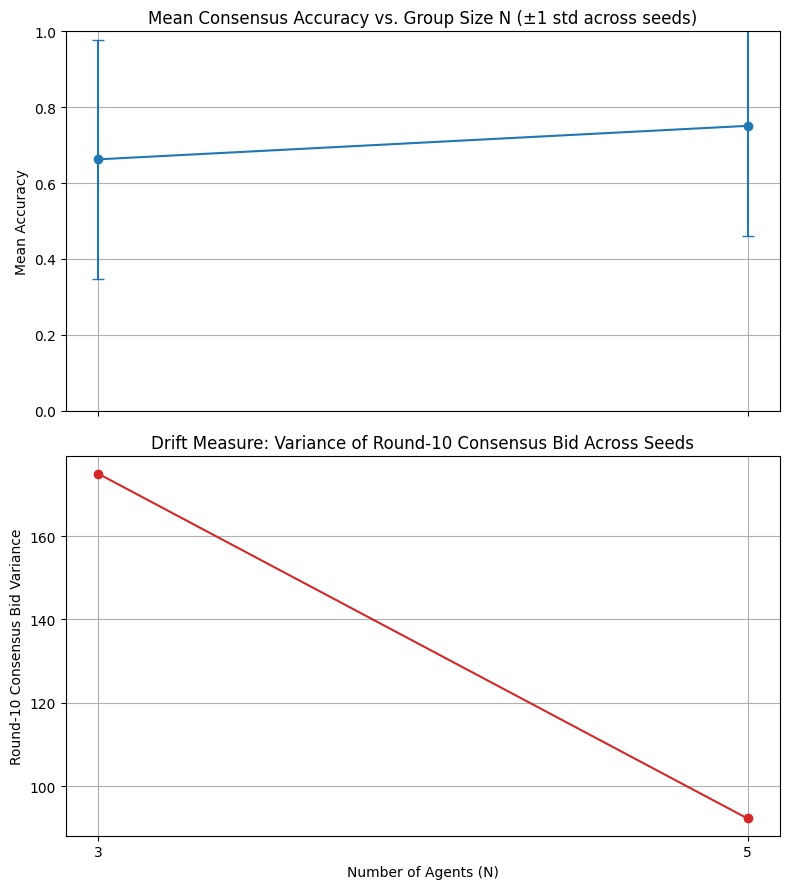

In [14]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 9), sharex=True)

ax1.errorbar(N_VALUES, mean_accuracy_by_N, yerr=std_accuracy_by_N, fmt='-o', capsize=4, color="tab:blue")
ax1.set_ylabel("Mean Accuracy")
ax1.set_ylim(0, 1)
ax1.set_title("Mean Consensus Accuracy vs. Group Size N (\u00b11 std across seeds)")
ax1.grid(True)

ax2.plot(N_VALUES, bid_variance_by_N, '-o', color="tab:red")
ax2.set_xlabel("Number of Agents (N)")
ax2.set_ylabel("Round-10 Consensus Bid Variance")
ax2.set_title("Drift Measure: Variance of Round-10 Consensus Bid Across Seeds")
ax2.set_xticks(N_VALUES)
ax2.grid(True)

plt.tight_layout()
plt.savefig("drift_selection_plot.png", dpi=150)
plt.show()

## Additional Visualizations
Consensus bid trajectories, confidence trends, bid-entropy across agents, and the round-10 bid
distribution — each saved to its own PNG file.

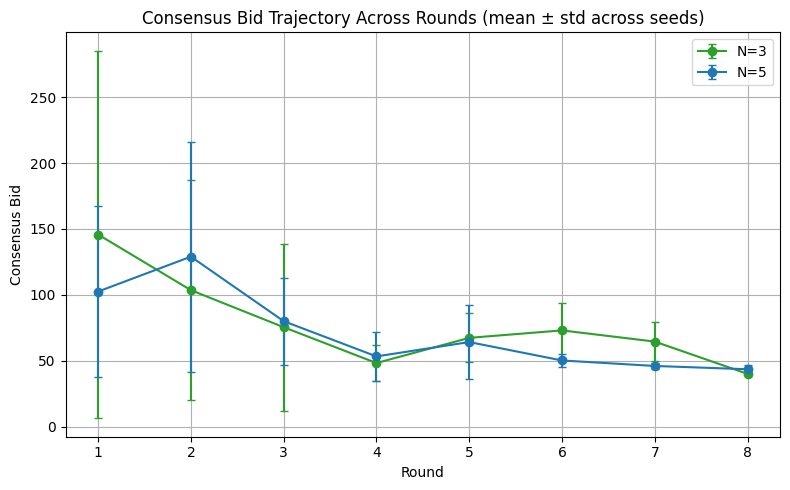

In [15]:
# Consensus bid trajectory (mean +/- std across seeds) per round, one line per N
fig, ax = plt.subplots(figsize=(8, 5))
colors = {3: "tab:green", 5: "tab:blue", 10: "tab:red"}

for N in N_VALUES:
    trials = sweep_results[N]
    max_rounds = max(len(t["consensus_log"]) for t in trials)
    per_round_values = [[] for _ in range(max_rounds)]
    for t in trials:
        for r, bid in enumerate(t["consensus_log"]):
            per_round_values[r].append(bid)

    means = [np.mean(v) if v else np.nan for v in per_round_values]
    stds = [np.std(v) if v else 0 for v in per_round_values]
    rounds = list(range(1, max_rounds + 1))
    ax.errorbar(rounds, means, yerr=stds, label=f"N={N}", capsize=3, marker='o', color=colors.get(N))

ax.set_xlabel("Round")
ax.set_ylabel("Consensus Bid")
ax.set_title("Consensus Bid Trajectory Across Rounds (mean \u00b1 std across seeds)")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig("consensus_trajectory.png", dpi=150)
plt.show()

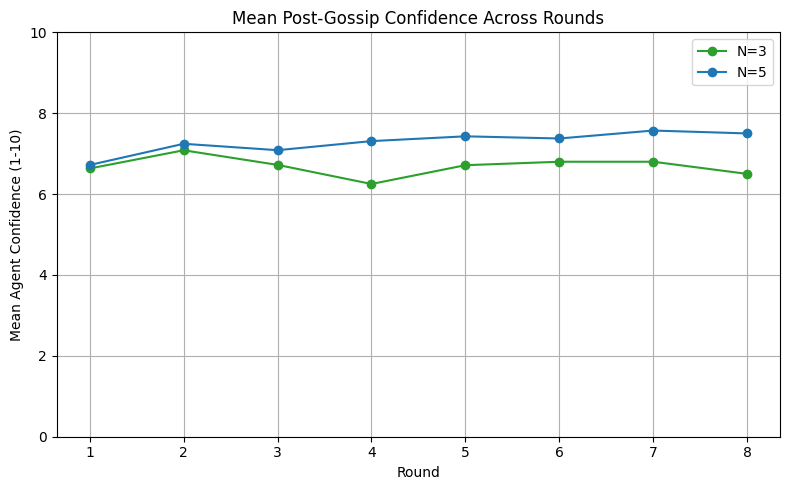

In [16]:
# Mean agent confidence per round, one line per N
fig, ax = plt.subplots(figsize=(8, 5))

for N in N_VALUES:
    trials = sweep_results[N]
    max_rounds = max(len(t["consensus_log"]) for t in trials)
    per_round_confs = [[] for _ in range(max_rounds)]
    for t in trials:
        for a in t["agent_names"]:
            for r, conf in enumerate(t["confidence_log"][a]):
                per_round_confs[r].append(conf)

    means = [np.mean(v) if v else np.nan for v in per_round_confs]
    rounds = list(range(1, max_rounds + 1))
    ax.plot(rounds, means, label=f"N={N}", marker='o', color=colors.get(N))

ax.set_xlabel("Round")
ax.set_ylabel("Mean Agent Confidence (1-10)")
ax.set_title("Mean Post-Gossip Confidence Across Rounds")
ax.set_ylim(0, 10)
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig("confidence_trend.png", dpi=150)
plt.show()

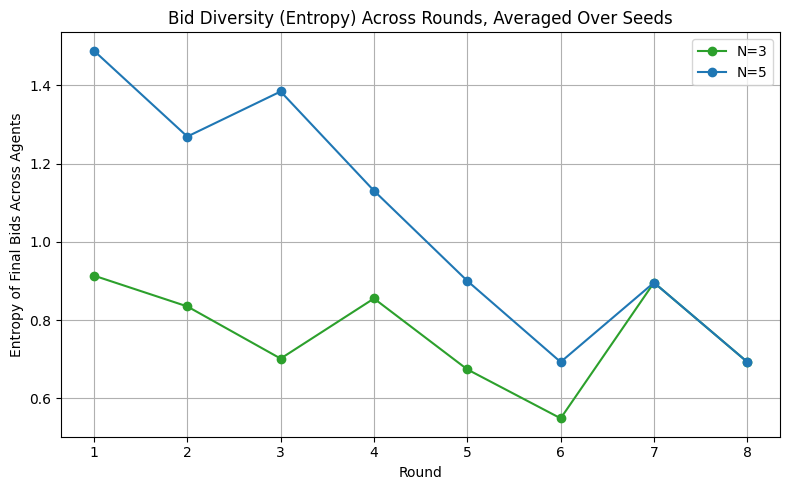

In [17]:
# Entropy of final bids across agents per round, averaged over seeds, one line per N
from scipy.stats import entropy

fig, ax = plt.subplots(figsize=(8, 5))

for N in N_VALUES:
    trials = sweep_results[N]
    max_rounds = max(len(t["consensus_log"]) for t in trials)
    per_round_entropy = [[] for _ in range(max_rounds)]

    for t in trials:
        for r in range(max_rounds):
            round_bids = []
            for a in t["agent_names"]:
                if r < len(t["bid_log"][a]):
                    round_bids.append(t["bid_log"][a][r])
            if round_bids:
                bid_counts = np.bincount(np.clip(np.round(round_bids).astype(int), 0, 999), minlength=1000)
                per_round_entropy[r].append(entropy(bid_counts + 1e-9))

    means = [np.mean(v) if v else np.nan for v in per_round_entropy]
    rounds = list(range(1, max_rounds + 1))
    ax.plot(rounds, means, label=f"N={N}", marker='o', color=colors.get(N))

ax.set_xlabel("Round")
ax.set_ylabel("Entropy of Final Bids Across Agents")
ax.set_title("Bid Diversity (Entropy) Across Rounds, Averaged Over Seeds")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig("bid_entropy.png", dpi=150)
plt.show()

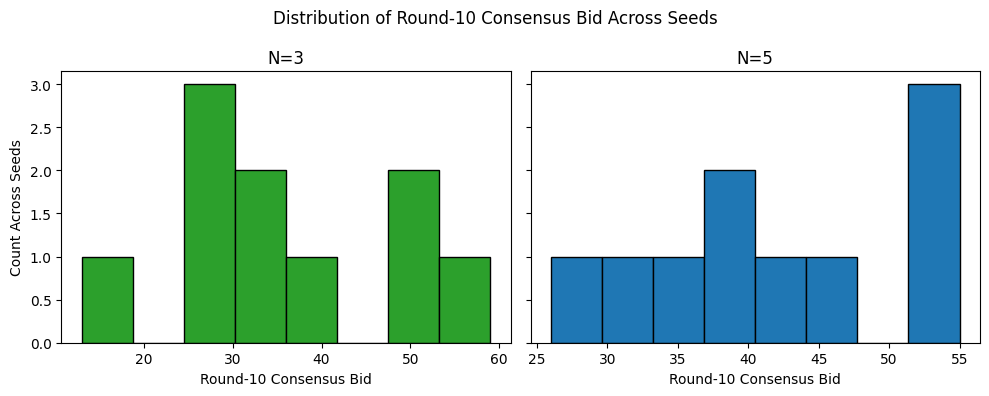

In [18]:
# Distribution of round-10 consensus bids across seeds, one histogram per N
fig, axes = plt.subplots(1, len(N_VALUES), figsize=(5 * len(N_VALUES), 4), sharey=True)

for ax, N in zip(axes, N_VALUES):
    trials = sweep_results[N]
    round10_bids = [t["consensus_log"][9] if len(t["consensus_log"]) >= 10 else t["consensus_log"][-1]
                     for t in trials]
    ax.hist(round10_bids, bins=8, color=colors.get(N), edgecolor="black")
    ax.set_title(f"N={N}")
    ax.set_xlabel("Round-10 Consensus Bid")

axes[0].set_ylabel("Count Across Seeds")
fig.suptitle("Distribution of Round-10 Consensus Bid Across Seeds")
plt.tight_layout()
plt.savefig("round10_bid_distribution.png", dpi=150)
plt.show()